# Alerta Temprana De Dificultades Financieras

### Proyecto Final - Optimización e Inteligencia Artificial


---

## Integrantes

<table>
  <tr><th>Nombre</th><th>Correo</th></tr>
  <tr><td>Dylan Ramirez Blanquicet</td><td><a href="mailto:dyramirezb@unal.edu.co">dyramirezb@unal.edu.co</a></td></tr>
  <tr><td>Andres Felipe Guerra Amaris</td><td><a href="mailto:anguerraa@unal.edu.co">anguerraa@unal.edu.co</a></td></tr>
  <tr><td>Jerónimo Hoyos Botero</td><td><a href="mailto:jhoyosbo@unal.edu.co">jhoyosbo@unal.edu.co</a></td></tr>
  <tr><td>Pedro Aristizabal Alzate</td><td><a href="mailto:paristizabala@unal.edu.co">paristizabala@unal.edu.co</a></td></tr>
</table>

## Índice
1. [Metodología, pipeline y ficha técnica](#sec-1)
    1. [Objetivo del proyecto](#sec-1-1)
    1. [Pipeline integral del proyecto (Diagrama de flujo)](#sec-1-2)
    1. [Ficha técnica del dataset, tipos y preprocesamiento](#sec-1-3)
    1. [Configuración del entorno e importaciones](#sec-1-4)
2. [Formateo y limpieza de datos](#sec-2)
    1. [Carga de datos](#sec-2-1)
    1. [Nombres de columnas](#sec-2-2)
    1. [Variables financieras](#sec-2-3)
    1. [NIT, CIIU y año de corte](#sec-2-4)
    1. [Duplicados](#sec-2-5)
    1. [Ciudad de domicilio](#sec-2-6)
    1. [Departamento y región](#sec-2-7)
    1. [Razón social por NIT](#sec-2-8)
    1. [Activos totales en cero](#sec-2-9)
    1. [Entidades de Supersalud](#sec-2-10)
3. [Análisis exploratorio (EDA)](#sec-3)
    1. [Univariado y distribuciones](#sec-3-1)
    1. [Concentración económica y territorial](#sec-3-2)
    1. [Salud financiera y riesgo](#sec-3-3)
    1. [Relaciones multivariadas y persistencia](#sec-3-4)
    1. [Conclusiones del EDA e implicaciones para el modelado](#sec-3-5)
4. [Preparación de datos](#sec-4)
    1. [Variable objetivo](#sec-4-1)
    1. [Variables nuevas](#sec-4-2)
    1. [Tabla final y exportación](#sec-4-3)
5. [Modelado](#sec-5)
    1. [Datos para el modelo](#sec-5-1)
    1. [Balanceo con SMOTE](#sec-5-2)
    1. [Regresión logística](#sec-5-3)
    1. [Naive Bayes](#sec-5-4)
    1. [K vecinos más cercanos](#sec-5-5)
    1. [SVM](#sec-5-6)
    1. [Árbol de decisión](#sec-5-7)
    1. [Random forest con grid search](#sec-5-8)
    1. [Random forest con búsqueda bayesiana](#sec-5-9)
    1. [Red neuronal](#sec-5-10)
    1. [Efecto de la optimización](#sec-5-11)
    1. [Comparación en test](#sec-5-12)
    1. [Matrices de confusión](#sec-5-13)
6. [Conclusiones finales](#sec-6)
7. [Referencias](#sec-7)

<a id="sec-1"></a>
## 1. Metodología, pipeline y ficha técnica del proyecto

<a id="sec-1-1"></a>
### 1.1 Objetivo del proyecto

Sistema de **alerta temprana** (reto *Datos al Ecosistema 2025*, MinTIC): dada la información de una empresa hoy, ¿tendrá **dificultades financieras** el año siguiente (pérdidas netas o patrimonio negativo)? Datos: [10.000 Empresas más Grandes del País](https://www.datos.gov.co/Comercio-Industria-y-Turismo/10-000-Empresas-mas-Grandes-del-Pa-s/6cat-2gcs/about_data).

<a id="sec-1-2"></a>
### 1.2 Pipeline del proyecto

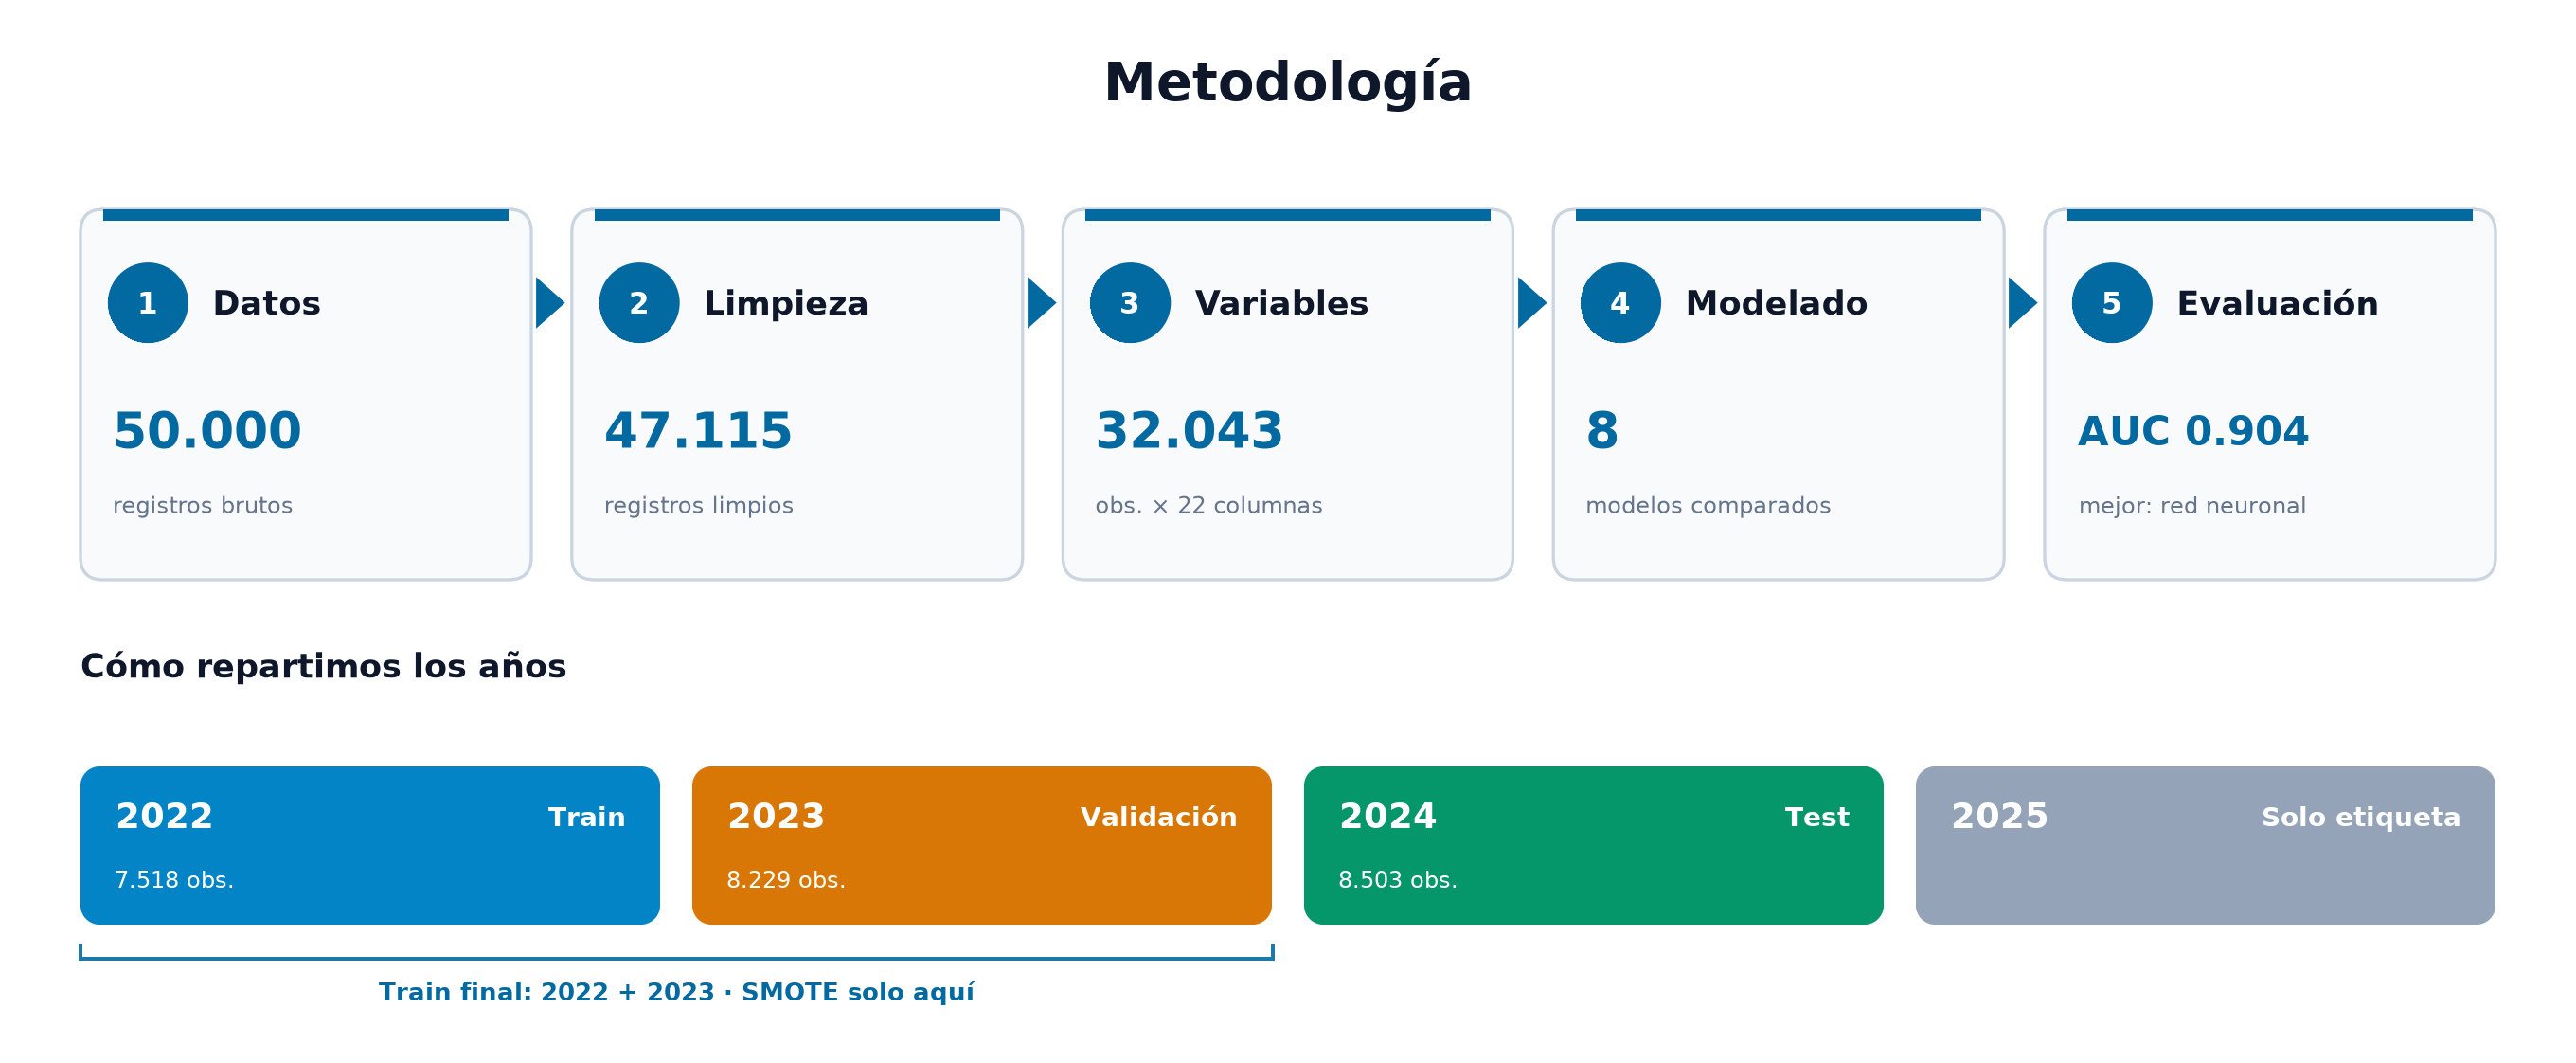

**Ideas clave:** validación en el tiempo (sin datos del futuro), SMOTE solo en entrenamiento y AUC-ROC como métrica, porque solo ~5 % de las empresas cae en dificultad.

<a id="sec-1-3"></a>
### 1.3 Ficha técnica de los datos

| Etapa | Registros | Nota |
|---|:---:|---|
| Bruto (2021-2025) | 50.000 | 5 cortes anuales de 10.000 empresas. |
| Sin Supersalud | 47.115 | Marcos contables especiales; no comparables. |
| `df_clean` | 32.043 | Empresas con año siguiente disponible. |
| ├ Train 2022 | 7.518 | 386 en dificultad (5.13 %). |
| ├ Val 2023 | 8.229 | 517 en dificultad (6.28 %). |
| ├ Test 2024 | 8.503 | 441 en dificultad (5.19 %). |
| └ 2021 | 7.793 | Fuera de los splits (no tiene año previo). |

Los modelos finales se entrenan con 2022 + 2023 (15.747 registros, 903 en dificultad).

**Variables.** Cifras en billones de COP. Identificadores (`nit`, `company_name`, `year`) y territoriales redundantes (`region`, `city`, `ciiu`) no entran al modelo.

| Tipo | Variables | Transformación |
|---|---|---|
| Categóricas | `supervisor`, `department`, `ciiu_division`, `macrosector` | `OneHotEncoder(min_frequency=20)` → 86 columnas |
| Financieras | ingresos, ganancia, activos, pasivos, patrimonio | `QuantileTransformer(normal)` + mediana |
| Creadas | `revenue_growth`, `asset_growth`, `current_distress`, `net_margin`, `debt_ratio`, `roa` | Igual; indicador de nulos en 4 de ellas |
| **Objetivo** | `next_year_distress` | 1 si el año siguiente hay pérdidas o patrimonio negativo |

`X_prep` queda con **101 columnas** (86 + 11 numéricas + 4 indicadores). **SMOTE** solo en entrenamiento; validación y test quedan intactos. Métrica principal: **AUC-ROC**; regla operativa `flag_at_risk` (10 % de mayor probabilidad).

<a id="sec-1-4"></a>
### 1.4 Configuración del entorno e importaciones

In [ ]:
# Colab no trae Optuna. imbalanced-learn solo se instala si falta
%pip install -q optuna imbalanced-learn

In [ ]:
# librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import urllib.request

from imblearn.over_sampling import SMOTE
import optuna
import torch
from torch import nn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

torch.manual_seed(42)

N_TRIALS = 30
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Carpeta donde se guardan las gráficas para el póster
IMG_DIR = Path("imgs")
IMG_DIR.mkdir(exist_ok=True)

# Estilo común de todas las gráficas
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 11, "legend.frameon": False,
})

print(device)

<a id="sec-2"></a>
## 2. Formateo y limpieza de datos

<a id="sec-2-1"></a>
### 2.1 Carga de datos

In [ ]:
# Ruta del archivo original
raw_path = Path('data/raw/10.000_Empresas_mas_Grandes_del_País.csv')


raw_path.parent.mkdir(parents=True, exist_ok=True)
url = 'https://www.datos.gov.co/api/views/6cat-2gcs/rows.csv?accessType=DOWNLOAD'
urllib.request.urlretrieve(url, raw_path)

# Cargar el CSV en un DataFrame
df = pd.read_csv(raw_path)

# (filas, columnas)
print(df.shape)
# Primeras 5 filas
df.head()

In [ ]:
# Información inicial de las columnas
df.info()

<a id="sec-2-2"></a>
### 2.2 Nombres de columnas
Se pasan a snake_case, sin tildes ni caracteres especiales, y se traducen al inglés.

In [ ]:
# Normalizar nombres de columnas a snake_case
df.columns = (
    # Quitar espacios al inicio y al final
    df.columns.str.strip()
    # Pasar todo a minúsculas
    .str.lower()
    # Separar cada letra de su tilde (á -> a + ´)
    .str.normalize("NFKD")
    # Pasar a ASCII descartando las tildes sueltas
    .str.encode("ascii", errors="ignore")
    # Convertir los bytes de vuelta a texto
    .str.decode("utf-8")
    # Eliminar signos de puntuación y símbolos
    .str.replace(r"[^\w\s]", "", regex=True)
    # Reemplazar espacios por guiones bajos
    .str.replace(r"\s+", "_", regex=True)
)

# Nombres en inglés
df = df.rename(columns={
    "razon_social": "company_name",
    "departamento_domicilio": "department",
    "ciudad_domicilio": "city",
    "ingresos_operacionales": "operating_revenue",
    "ganancia_perdida": "net_income",
    "total_activos": "total_assets",
    "total_pasivos": "total_liabilities",
    "total_patrimonio": "total_equity",
    "ano_de_corte": "year",
})

df.columns.tolist()

In [ ]:
# Variables categóricas
cat_cols = [
    "supervisor",
    "region",
    "department",
    "city",
    "ciiu",
    "macrosector",
]

# Variables financieras (en billones)
financial_cols = [
    "operating_revenue",
    "net_income",
    "total_assets",
    "total_liabilities",
    "total_equity",
]

<a id="sec-2-3"></a>
### 2.3 Variables financieras
Llegan como texto (con signo de pesos, comas y espacios) y se convierten a número.

In [ ]:
for col in financial_cols:
    # Quitar el signo de pesos, las comas de miles y los espacios
    clean_text = df[col].astype(str).str.replace(r"[$,\s]", "", regex=True)
    # Convertir a número (lo que no se pueda convertir queda vacío)
    df[col] = pd.to_numeric(clean_text, errors="coerce")

print("Valores que no se pudieron convertir:", df[financial_cols].isna().sum().sum())
df[financial_cols].head()

<a id="sec-2-4"></a>
### 2.4 NIT, CIIU y año de corte

In [ ]:
# NIT como texto y sin comas de miles
df['nit'] = df['nit'].astype(str).str.replace(',', '', regex=False)

# Código CIIU (actividad económica) con formato de 4 dígitos
df['ciiu'] = (
    # Partir de la columna original
    df['ciiu']
    # Convertir a texto
    .astype(str)
    # Quitar las comas de miles
    .str.replace(',', '', regex=False)
    # Quedarse con la parte antes del punto decimal
    .str.split('.').str[0]
    # Quitar espacios al inicio y al final
    .str.strip()
    # Rellenar con ceros a la izquierda hasta 4 dígitos
    .str.zfill(4)
)

# Quitar las comas del año y convertirlo a entero
df['year'] = df['year'].astype(str).str.replace(',', '', regex=False).astype(int)

# Revisar el resultado
# 2025 se necesita para saber qué empresas tuvieron dificultades en 2025 (conjunto de prueba)
message = "El CSV no incluye 2025: descargar la versión actual (ver README)"
assert df['year'].max() >= 2025, message

df[['nit', 'ciiu', 'year']].head()

<a id="sec-2-5"></a>
### 2.5 Duplicados

In [ ]:
# Análisis de duplicados
print(f'Cantidad de filas duplicadas: {df.duplicated().sum()}')

In [ ]:
# Duplicados considerando que cada empresa debería tener un único registro por año
dup_nit_year = df.duplicated(subset=["nit", "year"]).sum()
print(f'Filas con NIT repetido en el mismo año: {dup_nit_year}')

<a id="sec-2-6"></a>
### 2.6 Ciudad de domicilio
Se unifican variantes del mismo municipio (tildes, sufijos, nombres largos).

In [ ]:
# Función utilitaria para detectar variantes del mismo nombre agrupando por prefijo
def explore_prefix_variants(series: pd.Series, prefix_len: int = 3, min_items: int = 2) -> dict:
    """Encuentra prefijos que agrupan múltiples valores únicos."""
    unique_vals = pd.Series(series.dropna().unique())
    variants = (
        unique_vals.groupby(unique_vals.str[:prefix_len])
        .agg(list)
        .loc[lambda s: s.str.len() >= min_items]
    )
    return variants.to_dict()

# Variantes en ciudades
variants_city = explore_prefix_variants(df["city"], prefix_len=3, min_items=2)
for prefix, names in variants_city.items():
    print(f"Prefijo '{prefix}': {names}")

In [ ]:
# Función utilitaria para normalizar texto (quita tildes/diéresis y pasa a mayúsculas)
def normalize_text(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
        .str.strip()
        .str.normalize("NFKD")
        .str.encode("ascii", errors="ignore")
        .str.decode("utf-8")
        .str.upper()
    )

# 1. Normalización general de ciudad
df["city"] = normalize_text(df["city"])

# 2. Diccionario de corrección para inconsistencias detectadas
city_map = {
    # Aglutinaciones y separación de palabras
    "DON MATIAS": "DONMATIAS",
    "DOS QUEBRADAS": "DOSQUEBRADAS",
    "CAMPO ALEGRE": "CAMPOALEGRE",
    # Sufijos departamentales y aclaraciones
    "MAICAO GUAJIRA": "MAICAO",
    "MITU VAUPES": "MITU",
    "PUERTO GAITAN (MANACACIAS)": "PUERTO GAITAN",
    "LA PAZ (ROBLES)": "LA PAZ",
    "SAN ANDRES Y PROVIDENCIA": "SAN ANDRES",
    # Nombres oficiales largos vs. comunes
    "GUADALAJARA DE BUGA": "BUGA",
    "VILLA DE SAN DIEGO DE UBATE": "UBATE",
    "VILLA DE SAN DIEGO DE VILLA DE SAN DIEGO DE UBATE": "UBATE",
    "VILLA ROSARIO": "VILLA DEL ROSARIO",
    # Variantes que aparecen en 2025
    "EL ESPINAL": "ESPINAL",
    "EL GUAMO": "GUAMO",
    "GIRALDOTA": "GIRARDOTA",
    # Textos corruptos o truncados
    "SAN SEBASTIAN DE BUENAVISMAGDALENA": "SAN SEBASTIAN DE BUENAVISTA",
}

df["city"] = df["city"].replace(city_map)

In [ ]:
# Caso especial: Ferretería Central (Boyacá)
# 1. Localizar por coincidencia de la razón social
ferreteria_mask = df["company_name"].str.contains(
    # na=False: las razones sociales vacías cuentan como no coincidencia
    "FERRETERIA CENTRAL", na=False
# Y además que el departamento sea Boyacá
) & (df["department"] == "BOYACA")

# 2. Corregir ciudad y departamento
df.loc[ferreteria_mask, "city"] = "PUERTO BOYACA"
df.loc[ferreteria_mask, "department"] = "BOYACA"

# 3. Limpiar la razón social si absorbió el texto del departamento
df.loc[ferreteria_mask, "company_name"] = df.loc[
    ferreteria_mask, "company_name"
# Quitar "BOYACA" del final del nombre ($ = fin del texto) y los espacios sobrantes
].str.replace(r"BOYACA$", "", regex=True).str.strip()

<a id="sec-2-7"></a>
### 2.7 Departamento y región
Se unifican nombres, se corrigen cruces ciudad-departamento y se reconstruye la región desde el departamento.

In [ ]:
# Ver posibles variantes de department usando la función reutilizable
variants_dept = explore_prefix_variants(df["department"], prefix_len=3, min_items=1)
for prefix, names in variants_dept.items():
    print(f"Prefijo '{prefix}': {names}")

In [ ]:
# 1. Normalizar a mayúsculas y remover tildes usando la función utilitaria
df["department"] = normalize_text(df["department"])

# 2. Reubicar ciudades capitales que quedaron registradas en la columna de departamento
capitals_in_department = {
    "ARMENIA": "QUINDIO",
    "MONTERIA": "CORDOBA",
    "VALLEDUPAR": "CESAR",
}
mask_capitals = df["department"].isin(capitals_in_department)
df.loc[mask_capitals, "city"] = df.loc[mask_capitals, "department"]
df.loc[mask_capitals, "department"] = df.loc[mask_capitals, "department"].map(capitals_in_department)

# 3. Estandarizar nombres de departamentos duplicados
department_map = {
    "VALLE": "VALLE DEL CAUCA",
    "GUAJIRA": "LA GUAJIRA",
}
df["department"] = df["department"].replace(department_map)

In [ ]:
# FASE 1: Corregir departamentos mediante mapeo ciudad -> departamento consolidado
city_to_dept = {
    "MEDELLIN": "ANTIOQUIA",
    "BARRANQUILLA": "ATLANTICO",
    "BUCARAMANGA": "SANTANDER",
    "PALMIRA": "VALLE DEL CAUCA",
    "RIOHACHA": "LA GUAJIRA",
    "CUCUTA": "NORTE DE SANTANDER",
    "OCANA": "NORTE DE SANTANDER",
    "BUCARASICA": "NORTE DE SANTANDER",
    "FUNZA": "CUNDINAMARCA",
    "COTA": "CUNDINAMARCA",
    "MOSQUERA": "CUNDINAMARCA",
    "LA TEBAIDA": "QUINDIO",
    "ARJONA": "BOLIVAR",
}
mask_city_dept = df["city"].isin(city_to_dept)
df.loc[mask_city_dept, "department"] = df.loc[mask_city_dept, "city"].map(city_to_dept)

# Caso especial Bogotá (forzar siempre a Bogotá D.C. en ambas columnas)
mask_bogota = df["city"].isin(
    ["BOGOTA D.C.", "BOGOTA, D.C.", "BOGOTA"]
)
df.loc[mask_bogota, ["city", "department"]] = (
    "BOGOTA D.C."
)

# Caso especial Anserma en Valle -> Ansermanuevo
df.loc[
    (df["city"] == "ANSERMA")
    & (df["department"] == "VALLE DEL CAUCA"),
    "city",
] = "ANSERMANUEVO"

# Typo en Risaralda: Satuario -> Santuario
df.loc[
    (df["city"] == "SATUARIO")
    & (df["department"] == "RISARALDA"),
    "city",
] = "SANTUARIO"


# FASE 2: Homologación a nombres oficiales DIVIPOLA

official_names = {
    # Ciudades principales y municipios con prefijos/sufijos omitidos
    "CALI": "SANTIAGO DE CALI",
    "CARTAGENA": "CARTAGENA DE INDIAS",
    "CUCUTA": "SAN JOSE DE CUCUTA",
    "BUGA": "GUADALAJARA DE BUGA",
    "UBATE": "VILLA DE SAN DIEGO DE UBATE",
    "CARMEN DE VIBORAL": "EL CARMEN DE VIBORAL",
    "TUMACO": "SAN ANDRES DE TUMACO",
    "SANTAFE DE ANTIOQUIA": "SANTA FE DE ANTIOQUIA",
    "MARIQUITA": "SAN SEBASTIAN DE MARIQUITA",
    "PIENDAMO": "PIENDAMO - TUNIA",
    "SINCE": "SAN LUIS DE SINCE",
    "TOLU": "SANTIAGO DE TOLU",
    "INIRIDA GUAINIA": "INIRIDA",
    "ANTIOQUIA": "SANTA FE DE ANTIOQUIA",
}

# Aplicar reemplazos directos
df["city"] = df["city"].replace(official_names)

# Desambiguaciones contextuales en Antioquia
antioquia_disambiguations = {
    "SAN PEDRO": "SAN PEDRO DE LOS MILAGROS",
    "BOLIVAR": "CIUDAD BOLIVAR",
    "SANTUARIO": "EL SANTUARIO",
}
mask_ant = (df["department"] == "ANTIOQUIA") & (df["city"].isin(antioquia_disambiguations))
df.loc[mask_ant, "city"] = df.loc[mask_ant, "city"].map(antioquia_disambiguations)

In [ ]:
# Verificación: ya no deben existir cruces ciudad-departamento imposibles
expected_bad_pairs = {
    "BOGOTA D.C.": ["ANTIOQUIA", "CUNDINAMARCA"],
    "MEDELLIN": ["MAGDALENA"],
    "BARRANQUILLA": ["BOLIVAR", "SAN ANDRES Y PROVIDENCIA"],
    "CUCUTA": ["SANTANDER"],
}

# Una condición (máscara booleana) por cada ciudad
conditions = []
for city, departments in expected_bad_pairs.items():
    # Filas con esa ciudad y alguno de sus departamentos imposibles
    cond = (df["city"] == city) & (
        df["department"].isin(departments)
    )
    conditions.append(cond)

# Unir las máscaras como columnas y marcar las filas que cumplan al menos una
anomaly_mask = pd.concat(conditions, axis=1).any(axis=1)
# Filas anómalas con solo las columnas útiles para revisarlas
df_anomalies = df.loc[
    anomaly_mask,
    ["nit", "company_name", "city", "department", "year"],
]

print(f"Total de filas con cruces anómalos detectadas: {len(df_anomalies)}")
# to_string muestra la tabla completa, sin el índice
print(df_anomalies.to_string(index=False))

# 2. Contar cuántas ciudades únicas aparecen en más de un departamento
multi_department_cities = (
    # Agrupar por ciudad y tomar su departamento
    df.groupby("city")["department"]
    # Contar departamentos distintos por ciudad
    .nunique()
    # Dejar solo las ciudades con más de un departamento
    .loc[lambda x: x > 1]
)

print(f"\nTotal de nombres de ciudad asociados a >1 departamento: {len(multi_department_cities)}")
print(multi_department_cities.head(15))

In [ ]:
# Homónimos legítimos: municipios distintos con el mismo nombre
homonyms = ["EL SANTUARIO", "GRANADA", "GUAMAL", "LA UNION", "LA VEGA", "RESTREPO"]

# Ver en qué departamentos aparece cada homónimo
print(
    # Filtrar los homónimos y quedarse con ciudad y departamento
    df[df["city"].isin(homonyms)][
        ["city", "department"]
    ]
    # Quitar combinaciones repetidas
    .drop_duplicates()
    # Ordenar por ciudad y luego por departamento
    .sort_values(by=["city", "department"])
    # Convertir a texto sin el índice
    .to_string(index=False)
)

In [ ]:
# Verificar la lista final de departamentos/entidades territoriales
sorted_departments = sorted(df["department"].dropna().unique())
print(f"Total entidades territoriales encontradas: {len(sorted_departments)}")
print(sorted_departments)

In [ ]:
# En 2025 cambian los nombres de las regiones y en 2021-2024 hay asignaciones inconsistentes.
# Se reconstruye la región desde el departamento, con la clasificación de 2025.
region_by_department = (
    # Tomar solo 2025
    df[df["year"] == 2025]
    # Agrupar por departamento y tomar la región
    .groupby("department")["region"]
    # Quedarse con la región más frecuente de cada departamento
    .agg(lambda s: s.mode()[0])
    .to_dict()
)
# Guainía no aparece en 2025, así que se asigna igual que Vaupés y Vichada
region_by_department["GUAINIA"] = "LLANOS"

df["region"] = df["department"].map(region_by_department)
print("Registros sin región:", df["region"].isna().sum())
df.groupby("region")["department"].unique()

<a id="sec-2-8"></a>
### 2.8 Razón social por NIT
Un NIT puede tener varios nombres en distintos años. Se conserva el más reciente.

In [ ]:
# 1. Agrupar por NIT y contar cuántas razones sociales distintas tiene asociadas
nits_with_several_names = (
    # Agrupar por NIT y tomar la razón social
    df.groupby("nit")["company_name"]
    # Contar razones sociales distintas por NIT
    .nunique()
    # Dejar solo los NIT con más de una
    .loc[lambda x: x > 1]
)

print(f"Total de NITs con más de una razón social: {len(nits_with_several_names)}")

# 2. Filtrar el DataFrame original para inspeccionar los casos conflictivos
inconsistent_cases = (
    # Filtrar los NIT conflictivos y quedarse con NIT, nombre y año
    df[df["nit"].isin(nits_with_several_names.index)][
        ["nit", "company_name", "year"]
    ]
    # Quitar filas repetidas
    .drop_duplicates()
    # Ordenar por NIT y año
    .sort_values(by=["nit", "year"])
)

# Mostrar los primeros casos
print("\nEjemplo de empresas con nombres cambiantes:")
print(inconsistent_cases.head(20).to_string(index=False))

In [ ]:
# 1. Normalizar espacios en blanco internos y bordes
df["company_name"] = (
    # Partir de la columna original
    df["company_name"]
    # Convertir a texto
    .astype(str)
    # Quitar espacios al inicio y al final
    .str.strip()
    # Reducir espacios repetidos a uno solo
    .str.replace(r"\s+", " ", regex=True)
)

# 2. Obtener el nombre del año más reciente por NIT
latest_name = (
    # Ordenar por NIT y año (del más antiguo al más reciente)
    df.sort_values(by=["nit", "year"], ascending=[True, True])
    # Agrupar por NIT y tomar la razón social
    .groupby("nit")["company_name"]
    # Quedarse con el último nombre (el del año más reciente)
    .last()
)

# 3. Sobreescribir
# map: a cada fila le asigna el nombre más reciente de su NIT
df["company_name"] = df["nit"].map(latest_name)

In [ ]:
# Verificar que ya no existan NIT con más de un nombre asociado
print("NITs con más de un nombre:", (df.groupby("nit")["company_name"].nunique() > 1).sum())

<a id="sec-2-9"></a>
### 2.9 Activos totales en cero

In [ ]:
# Registros con activos en 0
zero_assets = df["total_assets"] == 0
print("Registros con activos en 0:", zero_assets.sum())

# ¿Dato faltante o redondeo? Se revisan los activos de esas mismas empresas en los otros años
zero_assets_nits = df.loc[zero_assets, "nit"]
same_companies = df["nit"].isin(zero_assets_nits) & ~zero_assets
median_other_years = df.loc[same_companies, "total_assets"].median()
print("Mediana de sus activos en otros años:", median_other_years)

En otros años esas empresas también tienen activos de casi 0: es el redondeo, no datos faltantes. Se conservan.

<a id="sec-2-10"></a>
### 2.10 Entidades de Supersalud
Supersalud desaparece del ranking en 2025, así que sus empresas se excluyen.

In [ ]:
# Registros vigilados por Supersalud
is_supersalud = df["supervisor"] == "SUPERSALUD"
records_per_year = df[is_supersalud].groupby("year").size()
print("Registros de Supersalud por año:", records_per_year.to_dict())

# Quitarlos
df = df[~is_supersalud].reset_index(drop=True)
print("Registros restantes:", len(df))

<a id="sec-3"></a>
## 3. Análisis exploratorio (EDA)

<a id="sec-3-1"></a>
### 3.1 Univariado y distribuciones

In [ ]:
# Estadísticas descriptivas con percentiles explícitos (en billones COP)
summary = df[financial_cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T
summary["skewness"] = df[financial_cols].skew()
summary["kurtosis"] = df[financial_cols].kurt()
summary.round(2)

In [ ]:
# Distribución de los ingresos operacionales con líneas de referencia
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(df["operating_revenue"], bins=40, log_scale=True, color="#2b5c8f", edgecolor="white", ax=ax)

med_rev = df["operating_revenue"].median()
p90_rev = df["operating_revenue"].quantile(0.9)
ax.axvline(med_rev, color="#d95f02", linestyle="--", linewidth=2, label=f"Mediana: {med_rev:.2f} billones")
ax.axvline(p90_rev, color="#555555", linestyle=":", linewidth=2, label=f"Percentil 90: {p90_rev:.2f} billones")

ax.set_title("Distribución de ingresos operacionales (escala log)")
ax.set_xlabel("Ingresos operacionales (billones COP)")
ax.set_ylabel("Número de empresas")
ax.legend()
plt.tight_layout()
# Guardar la gráfica en imgs para el póster
fig.savefig(IMG_DIR / "distribucion_ingresos.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# Las cifras vienen redondeadas a 0.01 billones: muchas empresas tienen exactamente el mismo valor
print("Valores distintos de ingresos:", df["operating_revenue"].nunique())

# Proporción de registros con ingresos de 0.05 billones o menos
low_revenue_share = (df["operating_revenue"] <= 0.05).mean()
print(f"Registros con ingresos ≤ 0.05 billones: {low_revenue_share:.0%}")

# Valores de ingresos más repetidos
df["operating_revenue"].value_counts().head(8)

In [ ]:
# Valores distintos por variable categórica
df[cat_cols].nunique()

In [ ]:
# Distribución categórica: porcentaje y número de empresas por barra
titles = {"supervisor": "Entidad supervisora", "region": "Región", "macrosector": "Macrosector"}
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, col in zip(axes, titles):
    counts = df[col].value_counts().sort_values()
    pcts = counts / counts.sum() * 100
    # La categoría más grande se resalta, el resto va en un tono más claro
    colors = ["#cfd8e6"] * (len(pcts) - 1) + ["#2b5c8f"]
    bars = ax.barh(pcts.index.astype(str), pcts.values, color=colors)

    # Porcentaje en negrita y número de registros al final de cada barra
    ax.bar_label(
        bars,
        labels=[f"{p:.1f} %  ({n:,})" for p, n in zip(pcts, counts)],
        padding=4, fontsize=10,
    )
    ax.set_title(titles[col], fontsize=14, pad=12)
    ax.set_xlabel("% de los registros")
    # Espacio a la derecha para que las etiquetas no se corten
    ax.set_xlim(0, pcts.max() * 1.35)
    # No mostrar marcas por encima de 100 %
    ax.set_xticks([t for t in ax.get_xticks() if 0 <= t <= 100])
    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Distribución de los registros por variable categórica", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

<a id="sec-3-2"></a>
### 3.2 Concentración económica y territorial
Análisis de disparidad territorial y concentración de ingresos (Ley de Pareto).

In [ ]:
# Top 10 departamentos con mayor concentración de grandes empresas
dept_counts = df["department"].value_counts()
top_counts = dept_counts.head(10).sort_values()
top_depts = top_counts / dept_counts.sum() * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
# El departamento líder se resalta, el resto va en un tono más claro
colors = ["#cfd8e6"] * (len(top_depts) - 1) + ["#2b5c8f"]
bars = ax.barh(top_depts.index.astype(str), top_depts.values, color=colors)

# Porcentaje y número de registros al final de cada barra
ax.bar_label(
    bars,
    labels=[f"{p:.1f} %  ({n:,})" for p, n in zip(top_depts, top_counts)],
    padding=4, fontsize=10,
)
ax.set_title("Top 10 departamentos con mayor concentración de grandes empresas", fontsize=14, pad=12)
ax.set_xlabel("% de los registros del ranking")
# Espacio a la derecha para que las etiquetas no se corten
ax.set_xlim(0, top_depts.max() * 1.25)
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

# Cuánto suman los 10 departamentos frente al total
top_share = top_depts.sum()
ax.text(0.98, 0.04, f"Los 10 primeros suman {top_share:.1f} % del total",
        transform=ax.transAxes, ha="right", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="#cfd8e6"))

plt.tight_layout()
# Guardar la gráfica en imgs para el póster
fig.savefig(IMG_DIR / "top_departamentos.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# Concentración de ingresos: ¿Cuánto acapara el Top 100 año a año?
pareto_data = {}
for yr in sorted(df["year"].unique()):
    df_yr = df[df["year"] == yr].sort_values("operating_revenue", ascending=False)
    total_rev = df_yr["operating_revenue"].sum()
    top_100_rev = df_yr.iloc[:100]["operating_revenue"].sum()
    pareto_data[yr] = {
        "Ingresos totales (billones)": round(total_rev, 1),
        "Ingresos Top 100 (billones)": round(top_100_rev, 1),
        "% Acaparado por Top 100": f"{(top_100_rev / total_rev) * 100:.1f} %",
    }

pd.DataFrame(pareto_data).T

<a id="sec-3-3"></a>
### 3.3 Salud financiera y riesgo
Frecuencia de pérdidas netas y patrimonio negativo: conexión directa con el objetivo predictivo.

In [ ]:
# Tasa de dificultad financiera (pérdidas o patrimonio < 0) por macrosector
distress_series = (df["net_income"] < 0) | (df["total_equity"] < 0)
distress_by_sec = (distress_series.groupby(df["macrosector"]).mean() * 100).sort_values()
sector_counts = df["macrosector"].value_counts()
overall_rate = distress_series.mean() * 100

fig, ax = plt.subplots(figsize=(11, 5))
# Rojo si el sector está por encima de la tasa general, gris azulado si está por debajo
colors = ["#d95f02" if r > overall_rate else "#cfd8e6" for r in distress_by_sec]
bars = ax.barh(distress_by_sec.index.astype(str), distress_by_sec.values, color=colors)

# Porcentaje y número de registros del sector al final de cada barra
ax.bar_label(
    bars,
    labels=[f"{r:.1f} %  (de {sector_counts[s]:,})" for s, r in distress_by_sec.items()],
    padding=4, fontsize=10,
)
# Línea con la tasa de todo el ranking como referencia
ax.axvline(overall_rate, color="#333333", linestyle="--", linewidth=1.5)
ax.text(overall_rate, 1.01, f"Total: {overall_rate:.1f} %", transform=ax.get_xaxis_transform(),
        ha="center", va="bottom", fontsize=10)

ax.set_title("Tasa de empresas con dificultades financieras por macrosector", fontsize=14, pad=22)
ax.set_xlabel("% de empresas en dificultad (pérdidas o patrimonio < 0)")
# Espacio a la derecha para que las etiquetas no se corten
ax.set_xlim(0, distress_by_sec.max() * 1.3)
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
# Guardar la gráfica en imgs para el póster
fig.savefig(IMG_DIR / "dificultad_por_macrosector.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# Evolución temporal de la tasa de dificultades financieras (2021-2025)
distress_by_yr = (distress_series.groupby(df["year"]).mean() * 100)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(distress_by_yr.index, distress_by_yr.values, marker="o", color="#2b5c8f", linewidth=2.5, markersize=8)
# Etiqueta de cada punto
for yr, val in distress_by_yr.items():
    ax.annotate(f"{val:.1f} %", (yr, val), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=10)

ax.set_title("Tasa de empresas en dificultad financiera por año")
ax.set_xlabel("Año de corte")
ax.set_ylabel("% de empresas en dificultad")
ax.set_xticks(distress_by_yr.index)
ax.set_ylim(0, distress_by_yr.max() * 1.25)
plt.tight_layout()
# Guardar la gráfica en imgs para el póster
fig.savefig(IMG_DIR / "dificultad_por_anio.png", dpi=200, bbox_inches="tight")
plt.show()

<a id="sec-3-4"></a>
### 3.4 Relaciones multivariadas y persistencia
Estructura de correlación entre variables financieras, dispersión sectorial y permanencia longitudinal en el ranking.

In [ ]:
# Spearman: robusta a la fuerte asimetría (se muestra solo el triángulo inferior)
labels = ["Ingresos", "Ganancia", "Activos", "Pasivos", "Patrimonio"]
corr_matrix = df[financial_cols].corr(method="spearman")
corr_matrix.index = corr_matrix.columns = labels
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
    annot_kws={"fontsize": 11}, linewidths=2, linecolor="white",
    cbar_kws={"label": "Correlación de Spearman", "shrink": 0.8}, ax=ax,
)
ax.grid(False)
ax.tick_params(axis="y", rotation=0)
ax.set_title("Correlación entre variables financieras")
plt.tight_layout()
# Guardar la gráfica en imgs para el póster
fig.savefig(IMG_DIR / "correlacion_spearman.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# Ingresos por macrosector, ordenados por mediana; escala logarítmica por la fuerte asimetría
order = df.groupby("macrosector")["operating_revenue"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df, x="operating_revenue", y="macrosector", order=order, log_scale=True,
    color="#cfd8e6", linecolor="#2b5c8f", linewidth=1.2,
    flierprops={"marker": "o", "markersize": 2.5, "markerfacecolor": "#2b5c8f", "alpha": 0.35, "markeredgecolor": "none"},
    ax=ax,
)
ax.set_title("Ingresos operacionales por macrosector (escala log)")
ax.set_xlabel("Ingresos operacionales (billones COP)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

> **Boxplot en escala log:** una unidad en el eje equivale a una empresa 10 veces más grande. Minero tiene la mediana más alta y los atípicos más extremos.

In [ ]:
# Persistencia en el ranking: ¿cuántos años aparece cada empresa de los 5 posibles?
years_count = df.groupby("nit")["year"].nunique().value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
# Se resalta quienes están los 5 años
colors = ["#cfd8e6"] * (len(years_count) - 1) + ["#2b5c8f"]
bars = ax.bar(years_count.index.astype(str), years_count.values, color=colors)
ax.bar_label(bars, labels=[f"{v:.1f} %" for v in years_count.values], padding=3, fontsize=10)

ax.set_title("Persistencia en el ranking (años presentes de 5 posibles)")
ax.set_xlabel("Años registrados en el ranking")
ax.set_ylabel("% de empresas")
ax.set_ylim(0, years_count.max() * 1.15)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

In [ ]:
# Cobertura del ranking por año y supervisor
pd.crosstab(df["supervisor"], df["year"], margins=True, margins_name="Total")

<a id="sec-3-5"></a>
### 3.5 Conclusiones del EDA

1. **Colas pesadas** (asimetría > 15, curtosis > 500) → `QuantileTransformer`.
2. **Desbalance (~5 %)** → SMOTE, AUC-ROC y `flag_at_risk` (la exactitud engaña).
3. **El sector importa:** 15.3 % de dificultad en Minero frente a 3.2 % en Comercio.
4. **El ciclo económico cambia las tasas** (3.5 % en 2021, 6.0 % en 2024, 5.0 % en 2025) → validar en el tiempo: entrenar 2022, ajustar 2023, probar 2024.
5. **Variables financieras correlacionadas** (Spearman 0.86 activos–pasivos, 0.81 activos–patrimonio).
6. **Rotación en el ranking:** solo 42.3 % de las empresas está los 5 años → se pierden las que salen y el modelo evalúa a las de actividad continua.

<a id="sec-4"></a>
## 4. Preparación de datos

<a id="sec-4-1"></a>
### 4.1 Variable objetivo
next_year_distress vale 1 si el año siguiente la empresa tiene pérdidas o patrimonio negativo.

In [ ]:
# Datos del año siguiente: se resta 1 al año para pegarlos a la fila del año actual
next_year = df[["nit", "year", "net_income", "total_equity"]].copy()
next_year["year"] -= 1
next_year.columns = ["nit", "year", "next_net_income", "next_equity"]

# Datos del año anterior: se suma 1 al año
prev_year = df[["nit", "year", "operating_revenue", "total_assets"]].copy()
prev_year["year"] += 1
prev_year.columns = ["nit", "year", "prev_revenue", "prev_assets"]

# Pegar ambos a cada fila (quedan vacíos si la empresa no aparece ese año)
df = df.merge(next_year, on=["nit", "year"], how="left")
df = df.merge(prev_year, on=["nit", "year"], how="left")

# Quitar los registros sin año siguiente (todo 2025 y las empresas que salen del ranking)
df = df.dropna(subset=["next_net_income"]).reset_index(drop=True)

# Variable objetivo: 1 si el año siguiente hay pérdidas o patrimonio negativo
next_losses = df["next_net_income"] < 0
next_negative_equity = df["next_equity"] < 0
df["next_year_distress"] = (next_losses | next_negative_equity).astype(int)

# Proporción (mean) y número (sum) de empresas con dificultades al año siguiente
df.groupby("year")["next_year_distress"].agg(["mean", "sum"]).round(3)

<a id="sec-4-2"></a>
### 4.2 Variables nuevas

In [ ]:
# Crecimiento frente al año anterior (0.1 = creció 10 %). Queda vacío si la empresa no estaba
df["revenue_growth"] = df["operating_revenue"] / df["prev_revenue"] - 1
df["asset_growth"] = df["total_assets"] / df["prev_assets"] - 1

# 1 si este año ya tiene pérdidas o patrimonio negativo
current_losses = df["net_income"] < 0
current_negative_equity = df["total_equity"] < 0
df["current_distress"] = (current_losses | current_negative_equity).astype(int)

# Indicadores financieros
df["net_margin"] = df["net_income"] / df["operating_revenue"]
df["debt_ratio"] = df["total_liabilities"] / df["total_assets"]
df["roa"] = df["net_income"] / df["total_assets"]

# División CIIU: los 2 primeros dígitos del código
df["ciiu_division"] = df["ciiu"].str[:2]

# Las divisiones por 0 (activos en 0) dan infinito: se dejan vacías
df = df.replace([np.inf, -np.inf], np.nan)

new_cols = [
    "revenue_growth",
    "asset_growth",
    "current_distress",
    "net_margin",
    "debt_ratio",
    "roa",
]
df[new_cols].describe().round(2)

In [ ]:
# ¿Las empresas con dificultades hoy las repiten el año siguiente? (proporción por fila)
pd.crosstab(df["current_distress"], df["next_year_distress"], normalize="index").round(3)

<a id="sec-4-3"></a>
### 4.3 Tabla final y exportación

In [ ]:
final_cols = [
    "nit",
    "company_name",
    "year",
    *cat_cols,
    "ciiu_division",
    *financial_cols,
    *new_cols,
    "next_year_distress",
]

df_clean = (
    # Ordenar por NIT y año
    df.sort_values(["nit", "year"])
    # Quedarse solo con las columnas finales
    [final_cols]
    # Reiniciar el índice desde 0
    .reset_index(drop=True)
)

df_clean.info()
df_clean.head()

In [ ]:
# Exportar resultados
output_path = 'data/proccesed/10.000_Empresas_mas_Grandes_del_País_proccesed.csv'
# Crear la carpeta si no existe (en Colab no existe)
Path(output_path).parent.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(output_path, index=False)

<a id="sec-5"></a>
## 5. Modelado

<a id="sec-5-1"></a>
### 5.1 Datos para el modelo

In [ ]:
# Variables del modelo (región y ciudad se omiten porque las cubre el departamento)
model_cat_cols = ["supervisor", "department", "ciiu_division", "macrosector"]
model_num_cols = financial_cols + new_cols

X = df_clean[model_cat_cols + model_num_cols]
y = df_clean["next_year_distress"].to_numpy()
year = df_clean["year"].to_numpy()

# División por año: Optuna entrena con 2022 y valida con 2023
is_train = year == 2022
is_val = year == 2023
is_test = year == 2024
# Los modelos finales se entrenan con 2022 y 2023
is_final = is_train | is_val

print("Filas:", is_train.sum(), is_val.sum(), is_test.sum())

In [ ]:
# Categóricas: una columna 0/1 por categoría. Las que tienen menos de 20 empresas se agrupan
categorical = OneHotEncoder(
    handle_unknown="infrequent_if_exist",
    min_frequency=20,
    sparse_output=False,
)

# Numéricas: llevar a distribución normal por cuantiles y rellenar los vacíos con la mediana
numerical = make_pipeline(
    QuantileTransformer(output_distribution="normal", random_state=42),
    SimpleImputer(strategy="median", add_indicator=True),
)

preprocessor = ColumnTransformer([
    ("cat", categorical, model_cat_cols),
    ("num", numerical, model_num_cols),
])

# Se ajusta solo con entrenamiento y se aplica a todas las filas
preprocessor.fit(X[is_train])
X_prep = preprocessor.transform(X)
X_prep.shape

In [ ]:
def flag_at_risk(prob):
    # Número de empresas que forman el 10 % más alto
    n_at_risk = round(len(prob) * 0.1)
    # Posiciones de las empresas, de mayor a menor riesgo
    order = np.argsort(-prob, kind="stable")
    # 1 = en riesgo, 0 = no. Si hay empates, igual se marca el número exacto de empresas
    flags = np.zeros(len(prob), dtype=int)
    flags[order[:n_at_risk]] = 1
    return flags

In [ ]:
def compute_metrics(prob, pred, actual):
    return {
        # Qué tan bien ordena a las empresas por riesgo: 0.5 = azar, 1 = perfecto
        "AUC": roc_auc_score(actual, prob),
        # Proporción de empresas bien clasificadas, con y sin dificultades
        "Accuracy": accuracy_score(actual, pred),
        # De las empresas marcadas en riesgo, cuántas tuvieron dificultades
        "Precisión": precision_score(actual, pred),
        # De las empresas que tuvieron dificultades, cuántas fueron marcadas
        "Recall": recall_score(actual, pred),
    }

<a id="sec-5-2"></a>
### 5.2 Balanceo con SMOTE

In [ ]:
# SMOTE toma una empresa con dificultades y una de sus 5 vecinas más parecidas,
# y crea una empresa nueva en un punto intermedio entre las dos
smote = SMOTE(random_state=42)

# Entrenamiento para buscar hiperparámetros (2022)
X_train_bal, y_train_bal = smote.fit_resample(X_prep[is_train], y[is_train])
# Entrenamiento de los modelos finales (2022 y 2023)
X_final_bal, y_final_bal = smote.fit_resample(X_prep[is_final], y[is_final])

# Empresas sin y con dificultades, antes y después
print("Antes:", np.bincount(y[is_final]))
print("Después:", np.bincount(y_final_bal))

<a id="sec-5-3"></a>
### 5.3 Regresión logística

In [ ]:
# Probabilidades y predicciones sí/no en test de cada modelo
prob_test = {}
pred_test = {}

logistic = LogisticRegression(max_iter=1000)
logistic.fit(X_final_bal, y_final_bal)

# Columna 1 = probabilidad de dificultades
prob_test["Regresión logística"] = logistic.predict_proba(X_prep[is_test])[:, 1]
pred_test["Regresión logística"] = flag_at_risk(prob_test["Regresión logística"])

<a id="sec-5-4"></a>
### 5.4 Naive Bayes

In [ ]:
naive_bayes = GaussianNB()
naive_bayes.fit(X_final_bal, y_final_bal)

# Sus probabilidades se pegan a 0 o a 1, así que muchas empresas empatan.
# La diferencia de log-probabilidades entre las dos clases ordena igual y sin empates
log_prob = naive_bayes.predict_joint_log_proba(X_prep[is_test])
prob_test["Naive Bayes"] = log_prob[:, 1] - log_prob[:, 0]
pred_test["Naive Bayes"] = flag_at_risk(prob_test["Naive Bayes"])

<a id="sec-5-5"></a>
### 5.5 K vecinos más cercanos

In [ ]:
auc_by_k = {}
for k in [25, 50, 100, 200, 400]:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_bal, y_train_bal)
    # Proporción de los k vecinos que tuvo dificultades
    prob_val = knn.predict_proba(X_prep[is_val])[:, 1]
    auc_by_k[k] = roc_auc_score(y[is_val], prob_val)

# k con mayor AUC de validación
best_k = max(auc_by_k, key=auc_by_k.get)
print("Mejor k:", best_k)

# Modelo final con 2022 y 2023
knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_final_bal, y_final_bal)

prob_test["K vecinos"] = knn.predict_proba(X_prep[is_test])[:, 1]
pred_test["K vecinos"] = flag_at_risk(prob_test["K vecinos"])

<a id="sec-5-6"></a>
### 5.6 SVM

In [ ]:
# Probar varios C: entrenar con 2022 balanceado y medir el AUC en 2023
auc_by_c = {}
for c_value in [0.1, 1, 10]:
    # C bajo = frontera más suave, C alto = frontera más pegada a los datos
    svm = SVC(kernel="rbf", C=c_value)
    svm.fit(X_train_bal, y_train_bal)
    # SVM no da probabilidades. Su puntaje es la distancia a la frontera y sirve igual para ordenar
    score_val = svm.decision_function(X_prep[is_val])
    auc_by_c[c_value] = roc_auc_score(y[is_val], score_val)

# C con mayor AUC de validación
best_c = max(auc_by_c, key=auc_by_c.get)
print("Mejor C:", best_c)

# Modelo final con 2022 y 2023
svm = SVC(kernel="rbf", C=best_c)
svm.fit(X_final_bal, y_final_bal)

prob_test["SVM"] = svm.decision_function(X_prep[is_test])
pred_test["SVM"] = flag_at_risk(prob_test["SVM"])

<a id="sec-5-7"></a>
### 5.7 Árbol de decisión

In [ ]:
# Probar varias profundidades: entrenar con 2022 balanceado y medir el AUC en 2023
auc_by_depth = {}
for depth in range(2, 13):
    # min_samples_leaf evita hojas con muy pocas empresas
    tree = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=20, random_state=42)
    tree.fit(X_train_bal, y_train_bal)
    prob_val = tree.predict_proba(X_prep[is_val])[:, 1]
    auc_by_depth[depth] = roc_auc_score(y[is_val], prob_val)

# Profundidad con mayor AUC de validación
best_depth = max(auc_by_depth, key=auc_by_depth.get)
print("Mejor profundidad:", best_depth)

# Árbol final con 2022 y 2023
tree = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=20, random_state=42)
tree.fit(X_final_bal, y_final_bal)

prob_test["Árbol de decisión"] = tree.predict_proba(X_prep[is_test])[:, 1]
pred_test["Árbol de decisión"] = flag_at_risk(prob_test["Árbol de decisión"])

<a id="sec-5-8"></a>
### 5.8 Random forest con grid search

**¿Por qué optimizar?** Los hiperparámetros por defecto no están pensados para datos financieros de colas pesadas, ~5 % de clase positiva y datos sintéticos de SMOTE: un modelo muy flexible sobreajusta y uno muy rígido ignora a las empresas en riesgo. Por eso se eligen con el **AUC de validación (2023)**: *grid search* como referencia, Optuna (búsqueda bayesiana) en un espacio más amplio y, en la red, Optuna también elige el optimizador (**Adam, RMSprop o SGD**) como un hiperparámetro más.

In [ ]:
X_search = np.vstack([X_train_bal, X_prep[is_val]])
y_search = np.concatenate([y_train_bal, y[is_val]])

fold = np.concatenate([np.full(len(y_train_bal), -1), np.zeros(is_val.sum())])
fixed_split = PredefinedSplit(fold)

In [ ]:
param_grid = {
    # Profundidad máxima de cada árbol (None = sin límite)
    "max_depth": [None, 10, 20],
    # Mínimo de empresas en cada hoja
    "min_samples_leaf": [1, 5, 10, 20],
    # Variables que mira cada división: raíz cuadrada del total o el 30 %
    "max_features": ["sqrt", 0.3],
}

grid_search = GridSearchCV(
    RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42),
    param_grid,
    scoring="roc_auc",
    cv=fixed_split,
    # El modelo final se entrena aparte con 2022 y 2023
    refit=False,
)
grid_search.fit(X_search, y_search)
print("Mejores hiperparámetros:", grid_search.best_params_)

# Modelo final con 2022 y 2023
rf_grid = RandomForestClassifier(
    n_estimators=300, n_jobs=-1, random_state=42, **grid_search.best_params_
)
rf_grid.fit(X_final_bal, y_final_bal)

prob_test["RF grid search"] = rf_grid.predict_proba(X_prep[is_test])[:, 1]
pred_test["RF grid search"] = flag_at_risk(prob_test["RF grid search"])

<a id="sec-5-9"></a>
### 5.9 Random forest con búsqueda bayesiana

In [ ]:
def rf_objective(trial):
    # Hiperparámetros que Optuna prueba en cada intento
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 50, log=True),
        "max_features": trial.suggest_float("max_features", 0.05, 0.6),
    }

    # Entrenar con 2022 balanceado y medir el AUC en 2023
    rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42, **params)
    rf.fit(X_train_bal, y_train_bal)
    prob_val = rf.predict_proba(X_prep[is_val])[:, 1]
    return roc_auc_score(y[is_val], prob_val)

In [ ]:
# Buscar los hiperparámetros con mayor AUC de validación
sampler = optuna.samplers.TPESampler(seed=42)
rf_study = optuna.create_study(direction="maximize", sampler=sampler)
rf_study.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=True)
print("Mejores hiperparámetros:", rf_study.best_params)

# Modelo final con 2022 y 2023
rf_bayes = RandomForestClassifier(
    n_estimators=300, n_jobs=-1, random_state=42, **rf_study.best_params
)
rf_bayes.fit(X_final_bal, y_final_bal)

prob_test["RF bayesiana"] = rf_bayes.predict_proba(X_prep[is_test])[:, 1]
pred_test["RF bayesiana"] = flag_at_risk(prob_test["RF bayesiana"])

<a id="sec-5-10"></a>
### 5.10 Red neuronal

In [ ]:
class NeuralNet(nn.Module):
    def __init__(self, n_inputs, n_layers, n_neurons, dropout):
        super().__init__()
        # Lista donde se van armando las capas
        layers = []
        # Cada capa oculta: lineal + ReLU + dropout
        for _ in range(n_layers):
            layers += [nn.Linear(n_inputs, n_neurons), nn.ReLU(), nn.Dropout(dropout)]
            # La siguiente capa recibe la salida de esta
            n_inputs = n_neurons
        # Capa de salida con un único valor
        layers.append(nn.Linear(n_inputs, 1))
        # Encadenar todas las capas en orden
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [ ]:
def train_net(params, X_np, y_np):
    X_t = torch.tensor(X_np, dtype=torch.float32, device=device)
    y_t = torch.tensor(y_np, dtype=torch.float32, device=device).unsqueeze(1)

    # Crear la red con los hiperparámetros elegidos
    net = NeuralNet(
        n_inputs=X_t.shape[1],
        n_layers=params["n_layers"],
        n_neurons=params["n_neurons"],
        dropout=params["dropout"],
    ).to(device)

    # Optimizador elegido en la búsqueda: Adam, RMSprop o SGD
    if params["optimizer"] == "Adam":
        optimizer = torch.optim.Adam(net.parameters(), lr=params["lr"])
    elif params["optimizer"] == "RMSprop":
        optimizer = torch.optim.RMSprop(net.parameters(), lr=params["lr"])
    elif params["optimizer"] == "SGD":
        # Momentum para que SGD no avance demasiado lento
        optimizer = torch.optim.SGD(net.parameters(), lr=params["lr"], momentum=0.9)
    else:
        raise ValueError(f"Optimizador desconocido: {params['optimizer']}")
    # Pérdida de clasificación binaria (sí / no)
    loss_fn = nn.BCEWithLogitsLoss()

    net.train()
    for _ in range(params["epochs"]):
        # Filas en orden aleatorio, partidas en lotes de 256
        batches = torch.randperm(len(X_t), device=device).split(256)
        for batch in batches:
            # Reiniciar los gradientes
            optimizer.zero_grad()
            # Error de la red en este lote
            loss = loss_fn(net(X_t[batch]), y_t[batch])
            # Calcular los gradientes y actualizar los pesos
            loss.backward()
            optimizer.step()

    return net

In [ ]:
def predict_net(net, X_np):
    # Modo evaluación: apaga el dropout
    net.eval()
    X_t = torch.tensor(X_np, dtype=torch.float32, device=device)

    # Sin calcular gradientes, porque solo se predice
    with torch.no_grad():
        output = net(X_t)

    # sigmoid convierte la salida en una probabilidad entre 0 y 1
    return torch.sigmoid(output).cpu().numpy().ravel()

In [ ]:
def net_objective(trial):
    # Hiperparámetros que Optuna prueba en cada intento
    params = {
        "n_layers": trial.suggest_int("n_layers", 1, 3),
        "n_neurons": trial.suggest_int("n_neurons", 16, 256, log=True),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        "epochs": trial.suggest_int("epochs", 5, 50),
        "optimizer": trial.suggest_categorical("optimizer", ["Adam", "RMSprop", "SGD"]),
    }

    # Entrenar con 2022 balanceado y medir el AUC en 2023
    net = train_net(params, X_train_bal, y_train_bal)
    prob_val = predict_net(net, X_prep[is_val])
    return roc_auc_score(y[is_val], prob_val)

In [ ]:
# Buscar los hiperparámetros con mayor AUC de validación
sampler = optuna.samplers.TPESampler(seed=42)
net_study = optuna.create_study(direction="maximize", sampler=sampler)
net_study.optimize(net_objective, n_trials=N_TRIALS, show_progress_bar=True)
print("Mejores hiperparámetros:", net_study.best_params)

# Red final con 2022 y 2023
net = train_net(net_study.best_params, X_final_bal, y_final_bal)

prob_test["Red neuronal"] = predict_net(net, X_prep[is_test])
pred_test["Red neuronal"] = flag_at_risk(prob_test["Red neuronal"])

<a id="sec-5-11"></a>
### 5.11 Efecto de la optimización
Cada búsqueda de hiperparámetros probó varias configuraciones y midió el AUC en validación (2023). La primera tabla compara la peor y la mejor configuración de cada modelo. La segunda muestra el optimizador de la red, que es uno de los hiperparámetros que buscó Optuna.

In [ ]:
# AUC de validación (2023) de todas las configuraciones que probó cada búsqueda
val_auc_by_model = {
    "K vecinos": list(auc_by_k.values()),
    "SVM": list(auc_by_c.values()),
    "Árbol de decisión": list(auc_by_depth.values()),
    "RF grid search": list(grid_search.cv_results_["mean_test_score"]),
    "RF bayesiana": rf_study.trials_dataframe()["value"].tolist(),
    "Red neuronal": net_study.trials_dataframe()["value"].tolist(),
}

tuning_rows = {}
for name, aucs in val_auc_by_model.items():
    tuning_rows[name] = {
        "Configuraciones": len(aucs),
        "Peor AUC": min(aucs),
        "Mejor AUC": max(aucs),
    }

# Una fila por modelo
tuning_effect = pd.DataFrame.from_dict(tuning_rows, orient="index")
# Lo que se gana al quedarse con la mejor configuración en vez de la peor
tuning_effect["Ganancia"] = tuning_effect["Mejor AUC"] - tuning_effect["Peor AUC"]
tuning_effect.sort_values("Ganancia", ascending=False).round(3)

In [ ]:
# Cada intento de Optuna en la red usó uno de los tres optimizadores
net_trials = net_study.trials_dataframe()

# Intentos, mejor AUC y AUC mediana de validación por optimizador
optimizer_comparison = (
    net_trials.groupby("params_optimizer")["value"]
    .agg(["count", "max", "median"])
)
optimizer_comparison.columns = ["Intentos", "Mejor AUC", "AUC mediana"]
optimizer_comparison.index.name = "Optimizador"
optimizer_comparison.sort_values("Mejor AUC", ascending=False).round(3)

<a id="sec-5-12"></a>
### 5.12 Comparación en test

In [ ]:
rows = {}
for name in prob_test:
    rows[name] = compute_metrics(prob_test[name], pred_test[name], y[is_test])

results = pd.DataFrame(rows).T
results.sort_values("AUC", ascending=False).round(3)

<a id="sec-5-13"></a>
### 5.13 Matrices de confusión

In [ ]:
# Modelos ordenados de mayor a menor AUC
order = results.sort_values("AUC", ascending=False).index
class_names = ["Sin dificultad", "En dificultad"]

fig, axes = plt.subplots(2, 4, figsize=(22, 11), sharex=True, sharey=True)

for ax, name in zip(axes.ravel(), order):
    # Conteos (filas = real, columnas = predicho) y porcentaje sobre cada clase real
    counts = confusion_matrix(y[is_test], pred_test[name])
    pct = counts / counts.sum(axis=1, keepdims=True)

    # El color usa el porcentaje por clase real, así todas las matrices se comparan en la misma escala
    sns.heatmap(
        pct, vmin=0, vmax=1, cmap="Blues", cbar=False, ax=ax,
        annot=[[f"{counts[i, j]:,}\n({pct[i, j]:.1%})" for j in range(2)] for i in range(2)],
        fmt="", annot_kws={"fontsize": 13}, linewidths=2, linecolor="white",
        xticklabels=class_names, yticklabels=class_names,
    )
    ax.grid(False)
    # Los aciertos (diagonal) se marcan con un borde
    for k in range(2):
        ax.add_patch(plt.Rectangle((k, k), 1, 1, fill=False, edgecolor="#1f3b5c", lw=2.5))

    # Métricas del modelo debajo de su matriz
    model_metrics = results.loc[name]
    ax.set_title(name, fontsize=14, fontweight="bold")
    ax.set_xlabel(
        f"AUC {model_metrics['AUC']:.3f}   Accuracy {model_metrics['Accuracy']:.3f}\n"
        f"Precisión {model_metrics['Precisión']:.3f}   Recall {model_metrics['Recall']:.3f}",
        fontsize=11,
    )
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11, rotation=90)

# Quitar el recuadro vacío (hay 8 modelos y 8 espacios, por si cambia el número)
for ax in axes.ravel()[len(order):]:
    ax.axis("off")

# Etiquetas de ejes compartidas
fig.supxlabel("Predicción (top 10 % de probabilidad = en dificultad)", fontsize=13)
fig.supylabel("Real", fontsize=13)
fig.suptitle("Matrices de confusión en test (2024), ordenadas por AUC", fontsize=17, fontweight="bold")
plt.tight_layout(rect=[0.02, 0.02, 1, 0.96])
# Guardar la gráfica en imgs para el póster
fig.savefig(IMG_DIR / "matrices_confusion.png", dpi=200, bbox_inches="tight")
plt.show()

<a id="sec-6"></a>
## 6. Conclusiones finales

### Técnicas

1. **AUC-ROC como métrica.** Solo ~5 % de las empresas cae en dificultad, así que la exactitud engaña. SMOTE se aplicó solo al entrenamiento.
2. **La red neuronal lidera, con Random Forest casi empatado:** AUC 0.904, exactitud 0.918, recall 0.669 (optimizador ganador: SGD con momentum). Los dos Random Forest quedan en 0.901 y la regresión logística en 0.898.
3. **Naive Bayes es el más débil (AUC 0.810):** su supuesto de independencia choca con variables muy correlacionadas (activos–pasivos 0.86).
4. **La optimización ayudó poco:** los cuatro mejores modelos están a 0.006 de AUC entre sí. La señal viene sobre todo de los ratios y de las transformaciones, y el ajuste fino aporta el último tramo.

### De negocio

`flag_at_risk` marca el **10 % de empresas con mayor probabilidad predicha**. Con la red neuronal captura **2 de cada 3** empresas que sí tuvieron dificultades (recall 0.669), y cada empresa marcada tiene unas **7 veces** más probabilidad de estar en dificultad que una al azar (precisión 0.347 frente a ~5 %).

Es un **sistema de alerta temprana viable** para la Superintendencia de Sociedades: concentra la supervisión en pocas empresas, anticipa un año, fue validado en el tiempo (2022 → 2023 → 2024) y el 10 % se puede ajustar a la capacidad de revisión.

<a id="sec-7"></a>
## 7. Referencias

* Superintendencia de Sociedades. *10.000 Empresas más Grandes del País* [Conjunto de datos]. Datos Abiertos Colombia (reto *Datos al Ecosistema 2025*, MinTIC). Consultado el 8 de octubre de 2026. https://www.datos.gov.co/Comercio-Industria-y-Turismo/10-000-Empresas-mas-Grandes-del-Pa-s/6cat-2gcs/about_data